In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
df = pd.read_csv('Stats.csv')
df.head()

,generated,zipf_slope,r_squared,productive_vocab_ratio,early_slope,mid_slope,slope_variance,slope_trajectory_change,slope_range,slope_std_err,...,pearson_corr,spearman_corr,rttr,maas,gap_variance,max_gap,gap_smoothness,hapax_ratio,dis_ratio,simpson_d
0,0.0,-0.683793,0.916469,0.320896,-0.611755,-1.154041,13.457341,0.542286,30.152578,0.012657,...,0.933940,0.827387,11.128094,0.019068,0.662627,11.0,0.123596,0.679104,0.119403,0.012872
1,0.0,-0.642639,0.916530,0.331878,-0.672721,-0.735930,10.742878,0.063210,26.686932,0.012872,...,0.869093,0.834430,10.723908,0.018375,0.125346,3.0,0.078947,0.668122,0.174672,0.011609
2,0.0,-0.714888,0.926001,0.343653,-0.708138,-0.984315,16.676998,0.276177,38.816765,0.011280,...,0.862902,0.844587,11.857703,0.019039,0.361454,9.0,0.090062,0.656347,0.151703,0.010604
3,0.0,-0.626878,0.906807,0.308357,-0.789542,-0.654571,15.553079,-0.134971,37.430490,0.010820,...,0.860926,0.815768,13.258188,0.015952,0.232183,7.0,0.069364,0.691643,0.146974,0.008800
4,0.0,-0.794565,0.945085,0.422713,-0.785589,-1.091652,20.913061,0.306063,46.787867,0.010792,...,0.823854,0.895526,10.815900,0.021842,0.244152,6.0,0.094937,0.577287,0.170347,0.010212


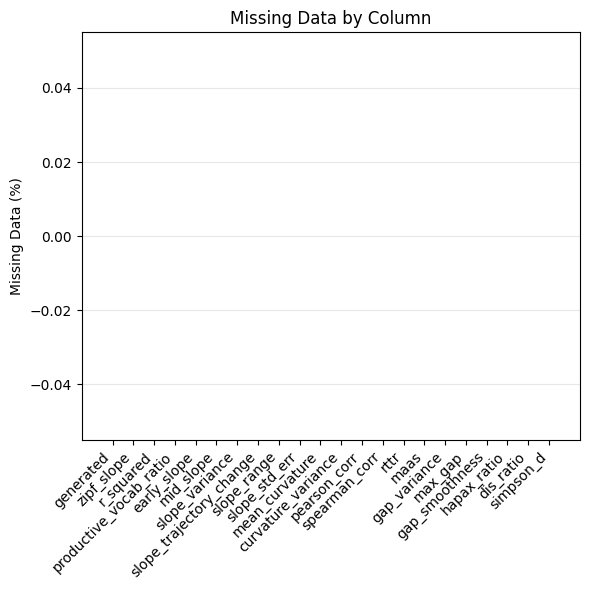

In [8]:
missing_data = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

plt.figure(figsize=(6, 6))
colors = ['red' if x > 0 else 'lightgreen' for x in missing_data.values]
bars = plt.bar(range(len(missing_data)), missing_data.values, color=colors, alpha=0.7)
plt.xticks(range(len(missing_data)), missing_data.index, rotation=45, ha='right')
plt.ylabel('Missing Data (%)')
plt.title('Missing Data by Column')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


In [7]:
df.dropna(axis=0, inplace=True)

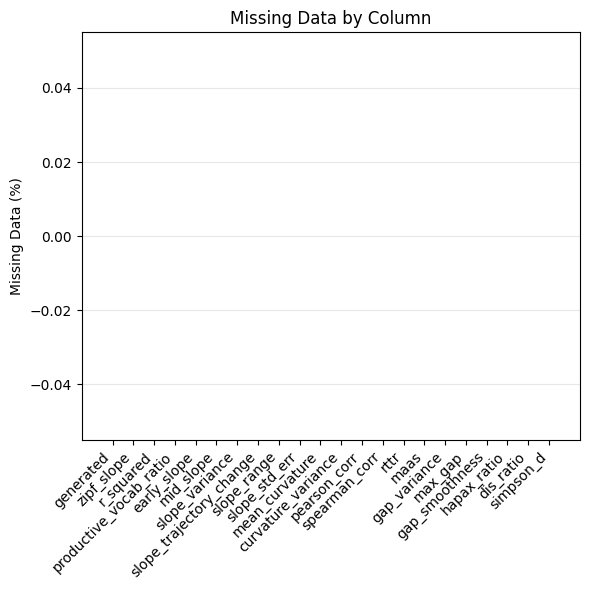

In [39]:
missing_data = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

plt.figure(figsize=(6, 6))
colors = ['red' if x > 0 else 'lightgreen' for x in missing_data.values]
bars = plt.bar(range(len(missing_data)), missing_data.values, color=colors, alpha=0.7)
plt.xticks(range(len(missing_data)), missing_data.index, rotation=45, ha='right')
plt.ylabel('Missing Data (%)')
plt.title('Missing Data by Column')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [40]:
#feature selection & splitting the data
X=df.drop(['generated','maas'],axis=1).copy()
y=df['generated'].copy()

In [41]:
X.shape

(487203, 20)

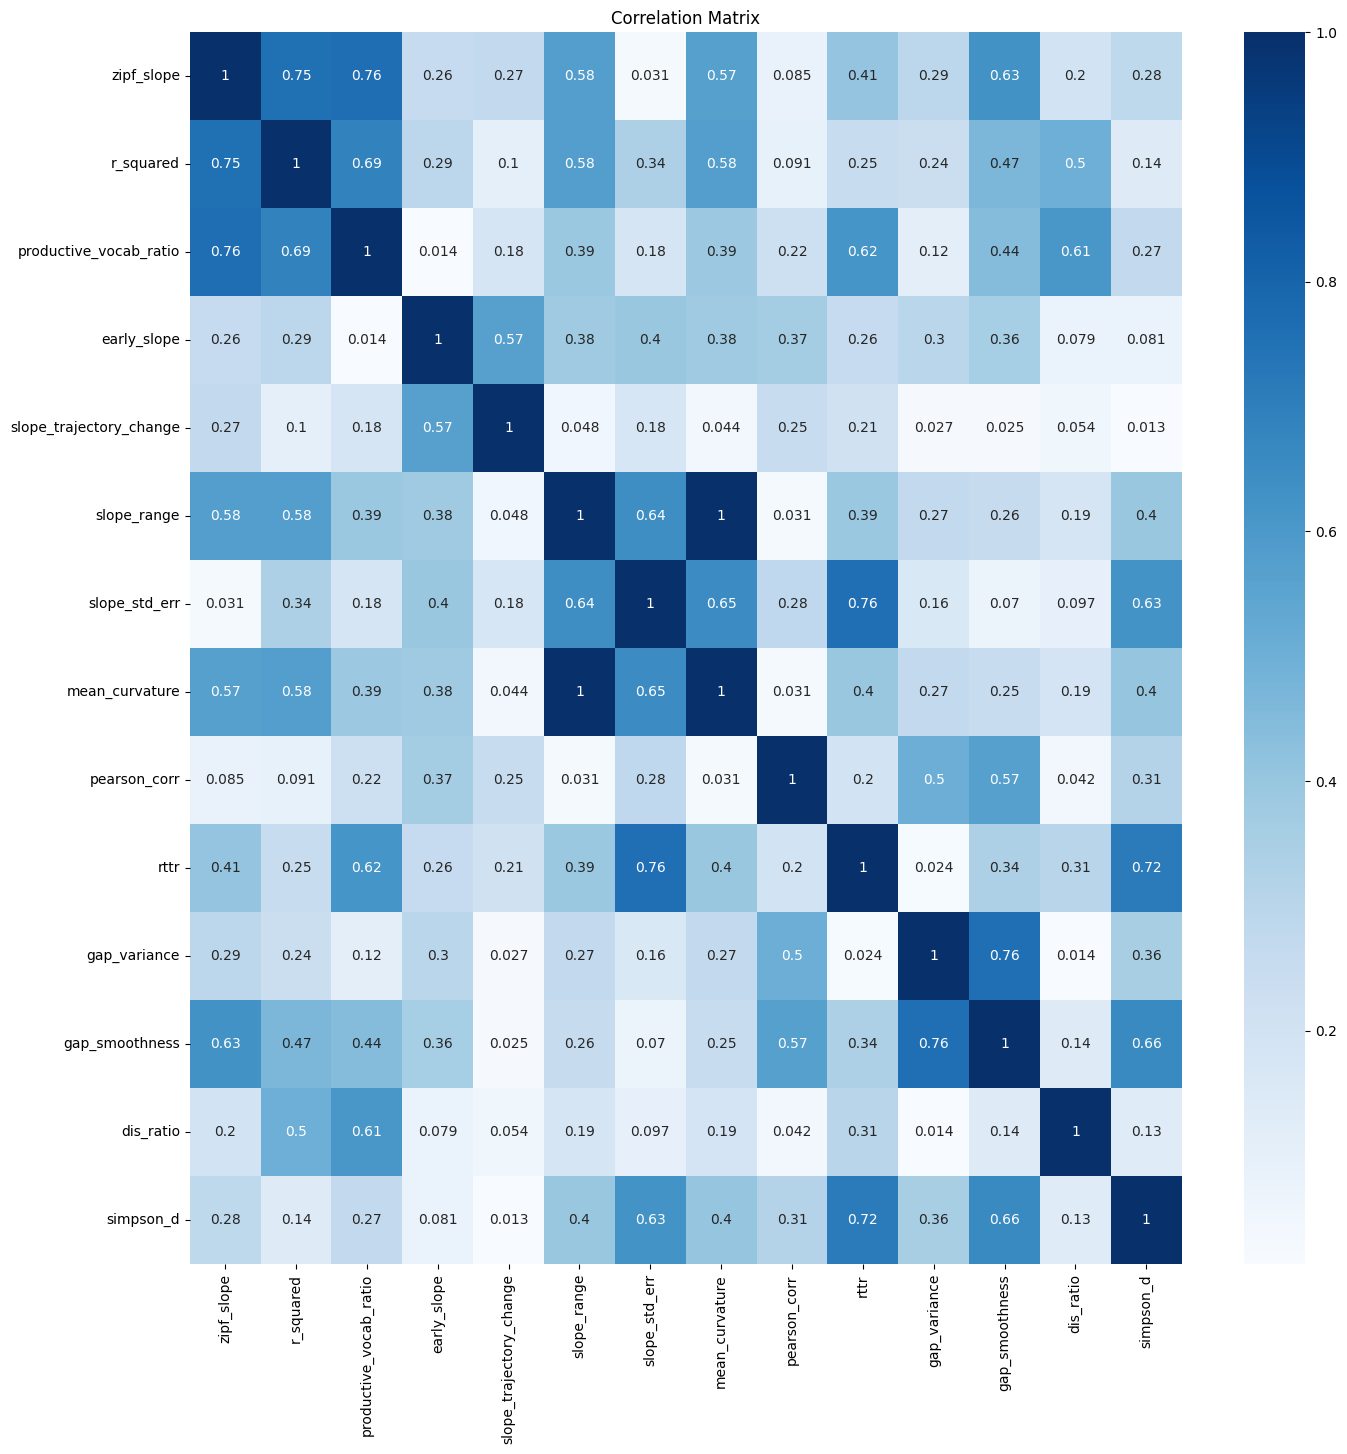

In [44]:
correlation_matrix = X.corr().abs()
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

plt.figure(figsize=(16, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', 
            xticklabels=X.columns, 
            yticklabels=X.columns)
plt.title('Correlation Matrix')
plt.show()

In [43]:
X.drop(['hapax_ratio','spearman_corr','slope_variance','max_gap','mid_slope','curvature_variance'],axis=1,inplace=True)

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=101, stratify=y
)

In [46]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=101,n_jobs = -1)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


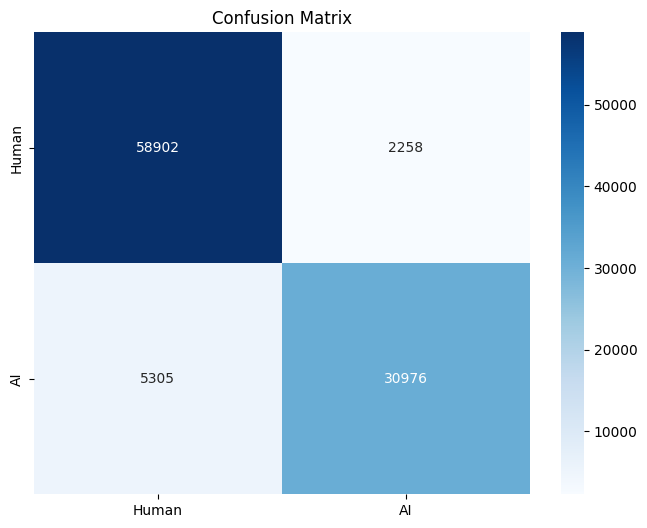

In [47]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Human', 'AI'], 
            yticklabels=['Human', 'AI'])
plt.title('Confusion Matrix')
plt.show()

In [32]:
print(classification_report(y_test, y_pred, 
                          target_names=['Human', 'AI']))

              precision    recall  f1-score   support

       Human       0.94      0.96      0.95     55600
          AI       0.93      0.90      0.91     31110

    accuracy                           0.94     86710
   macro avg       0.94      0.93      0.93     86710
weighted avg       0.94      0.94      0.94     86710



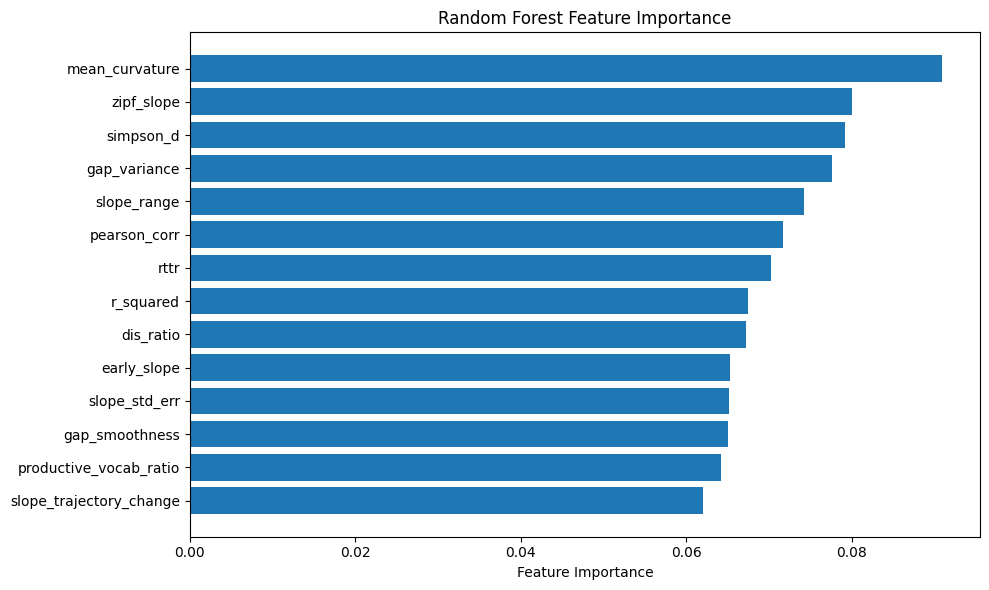

In [33]:
#feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()

In [57]:
output = df.drop(['pearson_p','spearman_p','unique_word'],axis=1)
output.to_csv('Final_Stats.csv', index=False)

In [58]:
output

,generated,zipf_slope,r_squared,pearson_corr,spearman_corr,rttr,maas
0,0.0,-0.683793,0.916469,0.933940,0.827387,11.128094,0.019068
1,0.0,-0.642639,0.916530,0.869093,0.834430,10.723908,0.018375
2,0.0,-0.714888,0.926001,0.862902,0.844587,11.857703,0.019039
3,0.0,-0.626878,0.906807,0.860926,0.815768,13.258188,0.015952
4,0.0,-0.794565,0.945085,0.823854,0.895526,10.815900,0.021842
...,...,...,...,...,...,...,...
487230,0.0,-0.615463,0.926035,0.916982,0.893542,7.144710,0.023963
487231,0.0,-0.660916,0.924865,0.990639,0.847857,9.350863,0.020875
487232,1.0,-0.566507,0.866703,0.912025,0.754935,10.925042,0.015907
487233,0.0,-0.816987,0.902847,0.820428,0.857100,7.125461,0.027954
